# Fine-tune DistilBERT for Amazon review sentiment

This notebook fine-tunes `distilbert-base-uncased-finetuned-sst-2-english` on a balanced, streamed subset of [`contemmcm/amazon_reviews_2013`](https://huggingface.co/datasets/contemmcm/amazon_reviews_2013). Reviews with 1–2 stars are **negative**, 4–5 stars are **positive**, and 3-star reviews are excluded.

It evaluates the original and fine-tuned model on the same held-out test set, plots the metric comparison and confusion matrix, then saves the fine-tuned model locally.

In [1]:
# Install missing notebook dependencies into the active kernel.
import importlib.util
import subprocess
import sys

required_packages = {
    "datasets": "datasets",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "seaborn": "seaborn",
    "accelerate": "accelerate",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import ClassLabel, Dataset, load_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

sns.set_theme(style="whitegrid")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


c:\Users\user\Amazon_scaper\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
BASE_MODEL = "distilbert-base-uncased-finetuned-sst-2-english"
DATASET_NAME = "contemmcm/amazon_reviews_2013"
DATASET_CONFIG = "electronics"
PREFERRED_SPLIT = "complete"
SAMPLES_PER_CLASS = 1_000  
TEST_SIZE = 0.20
MAX_LENGTH = 256
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 2e-5
OUTPUT_DIR = Path("models/distilbert-amazon-reviews")

print(f"Using GPU: {torch.cuda.is_available()}")
print(f"Training examples: up to {SAMPLES_PER_CLASS * 2:,}")

Using GPU: False
Training examples: up to 2,000


In [4]:
def first_present(record, candidates):
    for key in candidates:
        value = record.get(key)
        if value is not None and str(value).strip():
            return value
    return None


def binary_sentiment_label(record, score_names=None):
    """Map direct polarity or Amazon review-score ClassLabels to 0/1."""
    direct = first_present(record, ["label", "polarity", "sentiment"])
    if direct is not None:
        normalized = str(direct).strip().lower()
        if normalized in {"negative", "neg", "0"}:
            return 0
        if normalized in {"positive", "pos", "1"}:
            return 1

    value = first_present(record, ["review/score", "score", "rating"])
    if value is None:
        return None
    try:
        index_or_score = int(value)
    except (TypeError, ValueError):
        return None

    # ClassLabel index 0 can be decoded as '1 star'; polarity versions can
    # decode to 'negative'/'positive'. Both are handled here.
    if score_names is not None and 0 <= index_or_score < len(score_names):
        decoded = str(score_names[index_or_score]).strip().lower()
        if decoded in {"negative", "neg"}:
            return 0
        if decoded in {"positive", "pos"}:
            return 1
        try:
            index_or_score = int(decoded.split()[0])
        except (IndexError, ValueError):
            return None

    if index_or_score in (1, 2):
        return 0
    if index_or_score in (4, 5):
        return 1
    return None


def combined_review_text(record):
    summary = first_present(record, ["review/summary", "summary", "review/title", "title"]) or ""
    review = first_present(record, ["review/text", "text", "content", "review_body"]) or ""
    text = f"{summary}. {review}".strip(" .")
    return text if text else None


dataset_dict = load_dataset(DATASET_NAME, DATASET_CONFIG, streaming=True)
available_splits = list(dataset_dict)
split_name = PREFERRED_SPLIT if PREFERRED_SPLIT in available_splits else available_splits[0]
stream = dataset_dict[split_name]
score_names = getattr(stream.features.get("review/score"), "names", None)
print(f"Streaming {DATASET_CONFIG}/{split_name}; score encoding: {score_names or 'numeric'}")

# Stop once a balanced sample has been collected, so the full dataset is never downloaded.
rows_by_label = {0: [], 1: []}
for record in stream:
    label = binary_sentiment_label(record, score_names)
    text = combined_review_text(record)
    if label in rows_by_label and text and len(rows_by_label[label]) < SAMPLES_PER_CLASS:
        rows_by_label[label].append({"text": text, "label": label})
    if all(len(rows) >= SAMPLES_PER_CLASS for rows in rows_by_label.values()):
        break

if min(len(rows) for rows in rows_by_label.values()) == 0:
    raise RuntimeError("No binary sentiment examples were collected. Check the printed score encoding.")

rows = rows_by_label[0] + rows_by_label[1]
raw_dataset = Dataset.from_list(rows).cast_column("label", ClassLabel(names=["negative", "positive"]))
splits = raw_dataset.train_test_split(test_size=TEST_SIZE, seed=SEED, stratify_by_column="label")
print({name: len(split) for name, split in splits.items()})
display(pd.DataFrame(splits["train"][:3]))

c:\Users\user\Amazon_scaper\.venv311\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\datasets--contemmcm--amazon_reviews_2013. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Streaming electronics/complete; score encoding: ['1 star', '2 stars', '3 stars', '4 stars', '5 stars']


Casting the dataset: 100%|██████████| 2000/2000 [00:00<00:00, 199909.63 examples/s]


{'train': 1600, 'test': 400}


,text,label
0,Poorly made product. The Macally PS-AC4 Power ...,0
1,bubble bed. This bed sucks after 1 month I was...,0
2,Durable and functional replacement to the Appl...,1


In [5]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

tokenized = splits.map(tokenize, batched=True, remove_columns=["text"])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(prediction_output):
    logits, labels = prediction_output
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
    }

label_names = {0: "negative", 1: "positive"}

# Baseline evaluation: the pretrained SST-2 model, before Amazon adaptation.
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL, num_labels=2, id2label=label_names, label2id={v: k for k, v in label_names.items()}
)
baseline_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "baseline"),
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    report_to="none",
    disable_tqdm=False,
)
baseline_trainer = Trainer(
    model=baseline_model, args=baseline_args, data_collator=data_collator, compute_metrics=compute_metrics
)
baseline_metrics = baseline_trainer.evaluate(tokenized["test"])
print({key: round(value, 4) for key, value in baseline_metrics.items() if key.startswith("eval_")})

c:\Users\user\Amazon_scaper\.venv311\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
100%|██████████| 13/13 [00:39<00:00,  3.03s/it]

{'eval_loss': 0.6113, 'eval_model_preparation_time': 0.0, 'eval_accuracy': 0.8375, 'eval_precision': 0.9141, 'eval_recall': 0.745, 'eval_f1': 0.8209, 'eval_runtime': 44.0012, 'eval_samples_per_second': 9.091, 'eval_steps_per_second': 0.295}


In [6]:
# Fine-tune a fresh copy of the base model.
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL, num_labels=2, id2label=label_names, label2id={v: k for k, v in label_names.items()}
)
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=25,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer.train()
fine_tuned_metrics = trainer.evaluate()
trainer.save_model(str(OUTPUT_DIR / "final"))
tokenizer.save_pretrained(str(OUTPUT_DIR / "final"))
print(f"Saved fine-tuned model to {OUTPUT_DIR / 'final'}")

c:\Users\user\Amazon_scaper\.venv311\Lib\site-packages\transformers\training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
  8%|▊         | 25/300 [03:45<42:50,  9.35s/it]

{'loss': 0.3176, 'grad_norm': 17.97908592224121, 'learning_rate': 1.8333333333333333e-05, 'epoch': 0.25}


 17%|█▋        | 50/300 [07:39<38:42,  9.29s/it]

{'loss': 0.2574, 'grad_norm': 7.1892876625061035, 'learning_rate': 1.6666666666666667e-05, 'epoch': 0.5}


 25%|██▌       | 75/300 [12:14<40:29, 10.80s/it]

...

{'eval_loss': 0.27831482887268066, 'eval_accuracy': 0.935, 'eval_precision': 0.9438775510204082, 'eval_recall': 0.925, 'eval_f1': 0.9343434343434344, 'eval_runtime': 71.7724, 'eval_samples_per_second': 5.573, 'eval_steps_per_second': 0.181, 'epoch': 3.0}


100%|██████████| 300/300 [50:49<00:00, 10.16s/it]


{'train_runtime': 3049.1139, 'train_samples_per_second': 1.574, 'train_steps_per_second': 0.098, 'train_loss': 0.12045452018578848, 'epoch': 3.0}


100%|██████████| 13/13 [01:05<00:00,  5.06s/it]


Saved fine-tuned model to models\distilbert-amazon-reviews\final


,Base SST-2 model,Fine-tuned Amazon model
ACCURACY,0.838,0.938
PRECISION,0.914,0.958
RECALL,0.745,0.915
F1,0.821,0.936


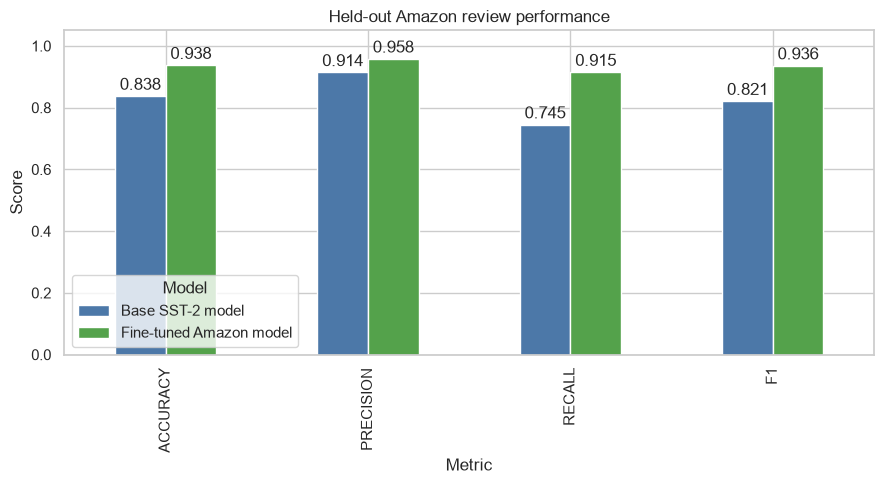

100%|██████████| 13/13 [00:39<00:00,  3.06s/it]


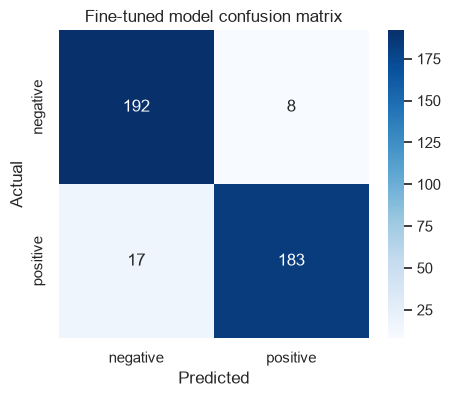

              precision    recall  f1-score   support

    negative      0.919     0.960     0.939       200
    positive      0.958     0.915     0.936       200

    accuracy                          0.938       400
   macro avg      0.938     0.938     0.937       400
weighted avg      0.938     0.938     0.937       400



In [7]:
# Compare models on exactly the same held-out Amazon-review test set.
metric_names = ["accuracy", "precision", "recall", "f1"]
comparison = pd.DataFrame({
    "Base SST-2 model": [baseline_metrics[f"eval_{name}"] for name in metric_names],
    "Fine-tuned Amazon model": [fine_tuned_metrics[f"eval_{name}"] for name in metric_names],
}, index=[name.upper() for name in metric_names])
display(comparison.style.format("{:.3f}").highlight_max(axis=1, color="#d9ead3"))

ax = comparison.plot.bar(figsize=(9, 5), ylim=(0, 1.05), color=["#4C78A8", "#54A24B"])
ax.set(title="Held-out Amazon review performance", xlabel="Metric", ylabel="Score")
ax.legend(title="Model")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2)
plt.tight_layout()
plt.show()

test_output = trainer.predict(tokenized["test"])
test_predictions = np.argmax(test_output.predictions, axis=-1)
cm = confusion_matrix(test_output.label_ids, test_predictions)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fine-tuned model confusion matrix")
plt.show()

print(classification_report(test_output.label_ids, test_predictions, target_names=["negative", "positive"], digits=3))